In [1]:
import os, sys

NB_DIR = os.getcwd()
QL_DIR = os.path.dirname(NB_DIR)
sys.path.append(QL_DIR)

import importlib
import numpy as np
import matplotlib.pyplot as plt
import runner

importlib.reload(runner)

PROJECT_ROOT = os.path.abspath(os.getcwd())
RUNS_DIR = os.path.join(PROJECT_ROOT, "runs")
QSTAR_DIR = os.path.join(RUNS_DIR, "qstar")
SQL_SHORT_DIR = os.path.join(RUNS_DIR, "sql_short")
SQL_COMPARE_DIR = os.path.join(RUNS_DIR, "sql_compare")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

os.makedirs(QSTAR_DIR, exist_ok=True)
os.makedirs(SQL_SHORT_DIR, exist_ok=True)
os.makedirs(SQL_COMPARE_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SEEDS = list(range(10))
SHORT_GAMMAS = [0.1, 0.9]
ALL_GAMMAS = [0.1, 0.3, 0.6, 0.9]
M_VALUES = [1, 4, 8, 16, 32]

SHORT_STEPS = 1100
LONG_STEPS = 5000
BATCH_LONG = 32
BASELINE_LONG = 1
SAMPLES_PER_PAIR = 1

ALPHA_MODE = "sql_linear"
ALPHA = 0.1
ALPHA_BETA = 1.0
ALPHA_TAU = 20000
USE_EXACT_BELLMAN = False

STRIDE_SHORT = 100
STRIDE_LONG = 100
FORCE_RERUN = False

COLOR_MAP_M = {
    1: "brown",
    4: "orange",
    8: "green",
    16: "red",
    32: "blue",
}

COLOR_MAP_GAMMA = {
    0.1: "green",
    0.3: "red",
    0.6: "blue",
    0.9: "brown",
}

def gamma_tag(gamma):
    return str(gamma).replace(".", "p")

def env_tag(env_name, map_name):
    return f"{env_name}_{map_name}" if env_name == "frozenlake" else env_name

def qstar_file(env_name, map_name, gamma):
    return os.path.join(QSTAR_DIR, f"Qstar_dp_{env_tag(env_name, map_name)}_gamma{gamma_tag(gamma)}.npy")

def sql_file(out_root, env_name, map_name, gamma, m, seed):
    mode_tag = "exact" if USE_EXACT_BELLMAN else f"K{SAMPLES_PER_PAIR}"
    alpha_tag = ALPHA_MODE.replace("_", "")
    return os.path.join(
        out_root,
        f"sql_{env_tag(env_name, map_name)}_m{m}_{mode_tag}_a{alpha_tag}_gamma{gamma_tag(gamma)}_seed{seed}.npz"
    )

def load_qstar(env_name, map_name, slippery, gamma):
    path = qstar_file(env_name, map_name, gamma)
    if os.path.exists(path):
        return np.load(path)

    tag, Q_star = runner.run_compute_Qstar_stationary_dp(
        env_name,
        map_name=map_name,
        slippery=slippery,
        gamma=gamma,
        seed=0,
        out_root=QSTAR_DIR,
    )

    path = os.path.join(QSTAR_DIR, f"{tag}.npy")
    return np.load(path)

def run_sql_curves(env_name, map_name, slippery, gammas, m_values, steps, out_root):
    runs = {}
    qstar_norms = {}

    for gamma in gammas:
        Q_star = load_qstar(env_name, map_name, slippery, gamma)
        qnorm = np.linalg.norm(Q_star)

        if qnorm < 1e-12:
            raise ValueError(f"||Q*|| too small for gamma={gamma}")

        qstar_norms[gamma] = qnorm
        runs[gamma] = {}

        for m in m_values:
            curves = []

            for seed in SEEDS:
                path = sql_file(out_root, env_name, map_name, gamma, m, seed)

                if FORCE_RERUN or not os.path.exists(path):
                    runner.run_speedy_uniform(
                        env_name,
                        map_name=map_name,
                        slippery=slippery,
                        seed=seed,
                        steps=steps,
                        batch_size=m,
                        samples_per_pair=SAMPLES_PER_PAIR,
                        gamma=gamma,
                        Q_star=Q_star,
                        alpha_mode=ALPHA_MODE,
                        alpha=ALPHA,
                        alpha_beta=ALPHA_BETA,
                        alpha_tau=ALPHA_TAU,
                        use_exact_bellman=USE_EXACT_BELLMAN,
                        out_root=out_root,
                    )

                data = np.load(path, allow_pickle=True)
                curves.append(np.asarray(data["dist_to_Qstar"], dtype=float))

            arr = np.stack(curves, axis=0)
            runs[gamma][m] = {
                "raw_mean": arr.mean(axis=0),
                "raw_std": arr.std(axis=0),
                "norm_mean": (arr / qnorm).mean(axis=0),
                "norm_std": (arr / qnorm).std(axis=0),
            }

    return runs, qstar_norms

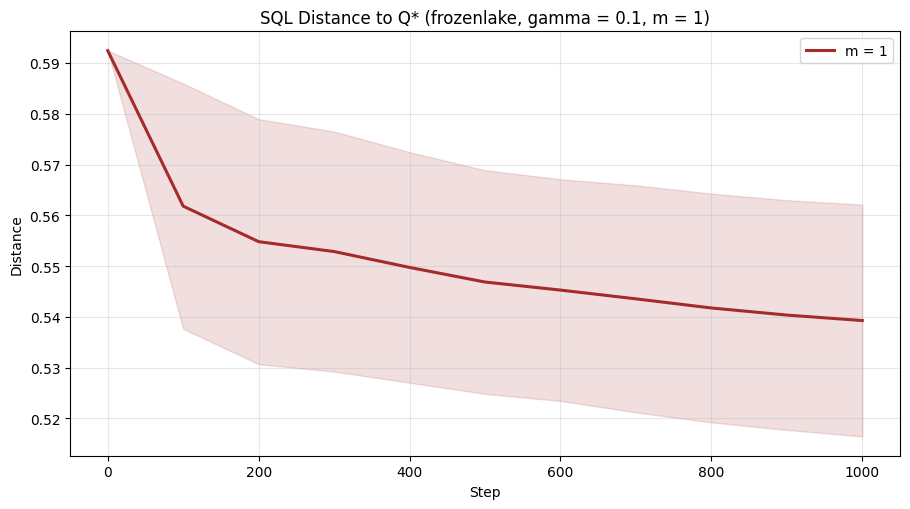

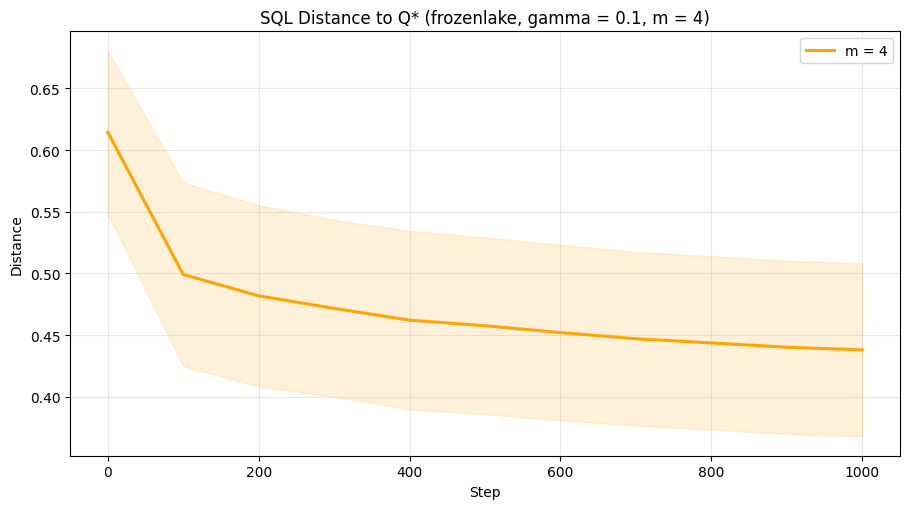

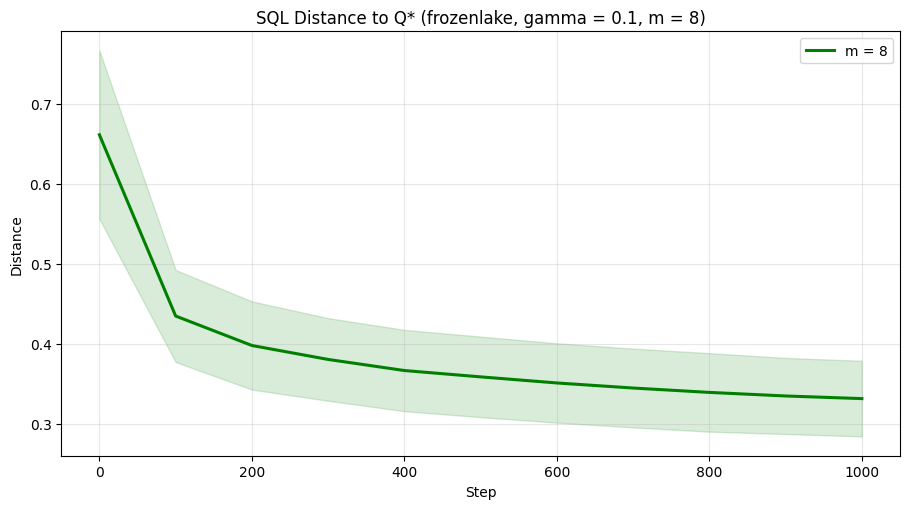

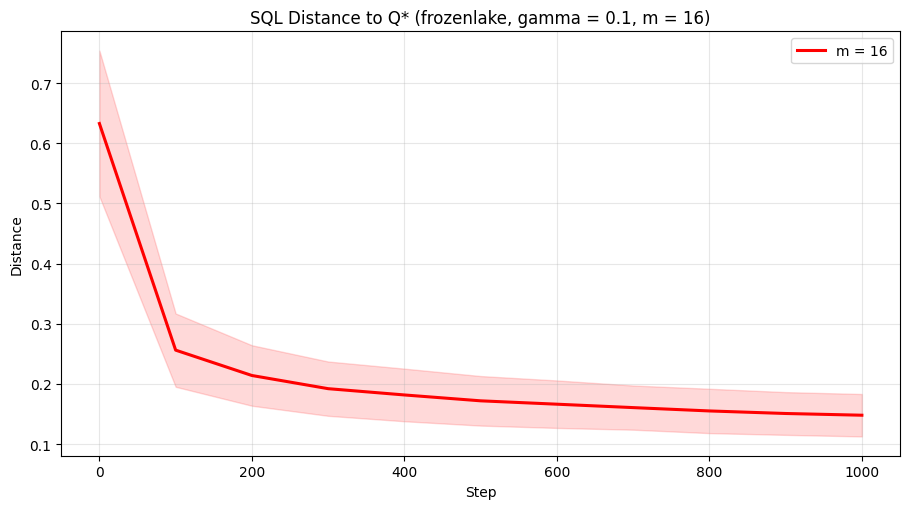

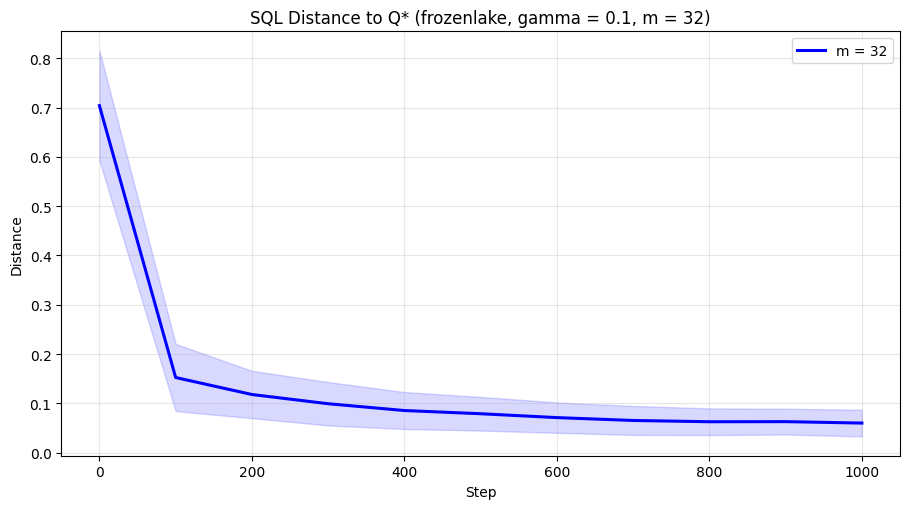

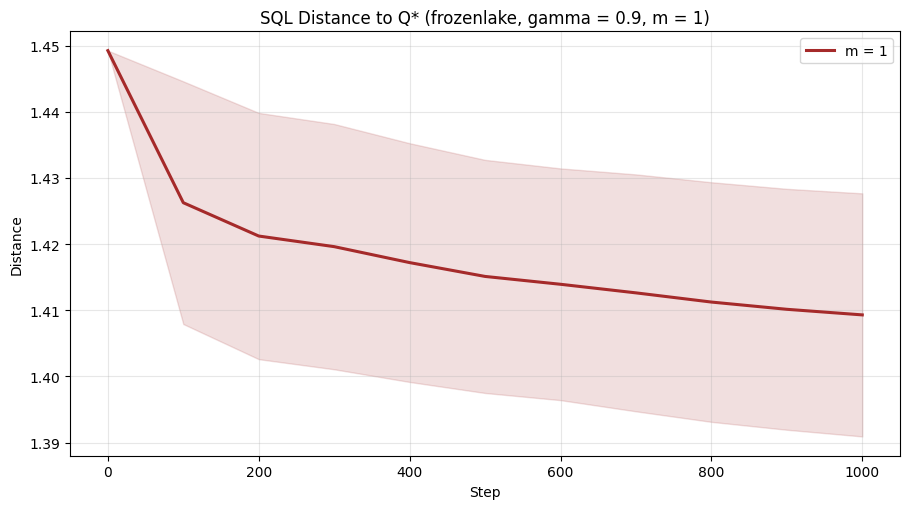

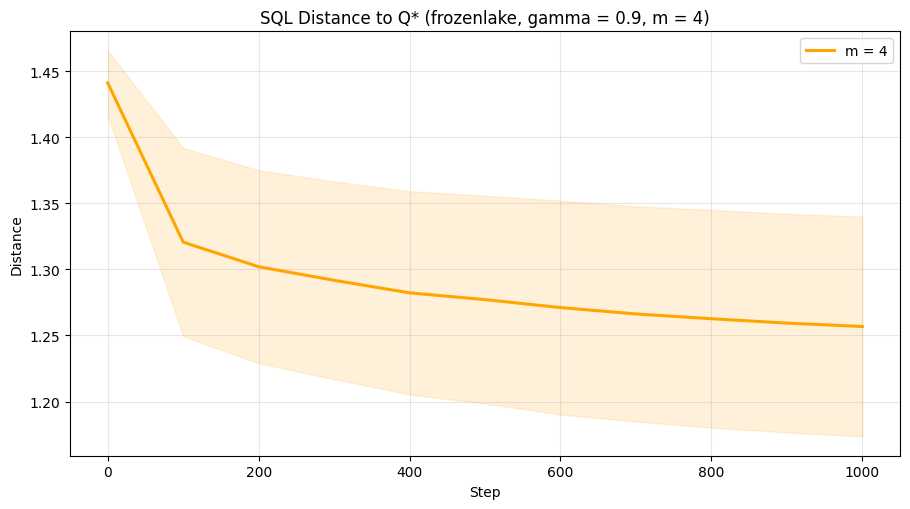

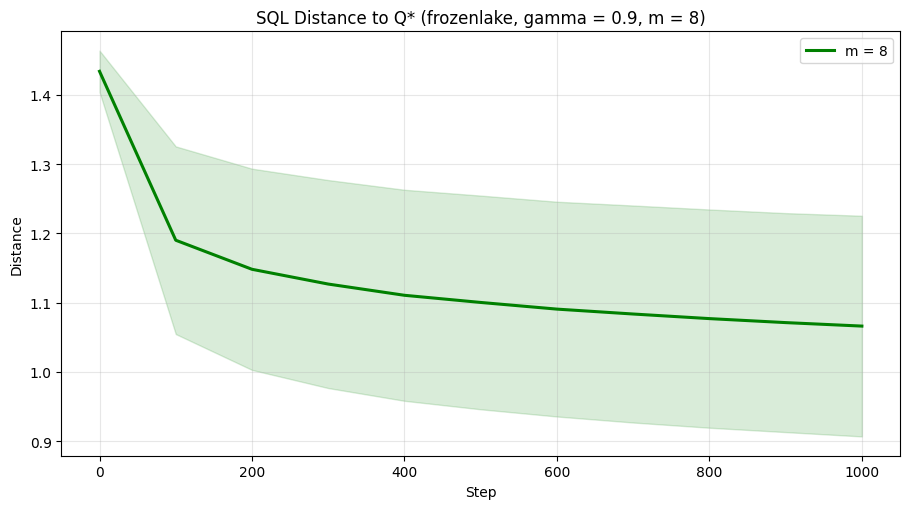

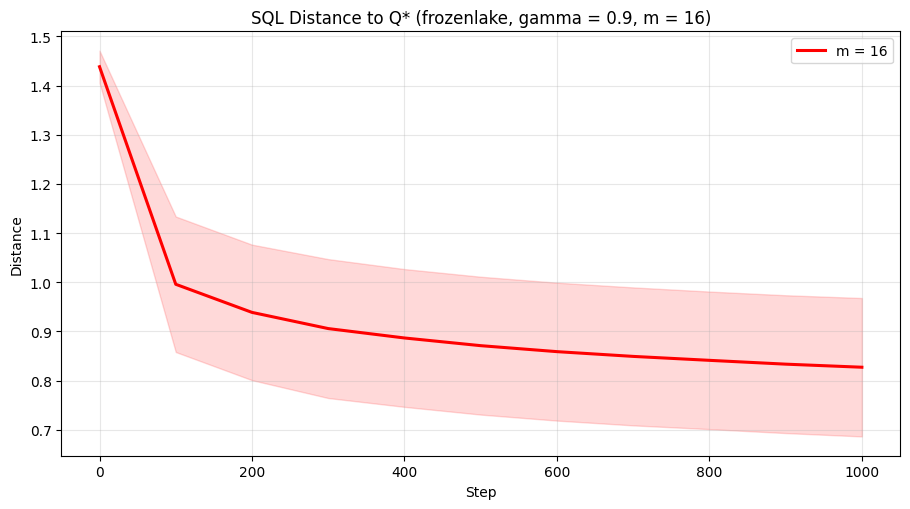

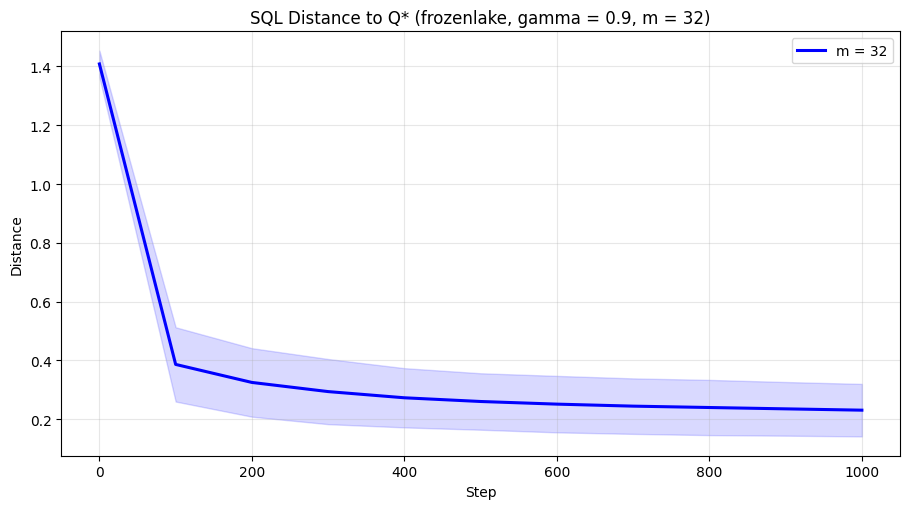

In [2]:
ENV_NAME = "frozenlake"
MAP_NAME = "4x4"
SLIPPERY = True

sql_short_runs, _ = run_sql_curves(
    env_name=ENV_NAME,
    map_name=MAP_NAME,
    slippery=SLIPPERY,
    gammas=SHORT_GAMMAS,
    m_values=M_VALUES,
    steps=SHORT_STEPS,
    out_root=SQL_SHORT_DIR,
)

for gamma in SHORT_GAMMAS:
    for m in M_VALUES:
        mean_y = sql_short_runs[gamma][m]["raw_mean"]
        std_y = sql_short_runs[gamma][m]["raw_std"]
        x = np.arange(len(mean_y))

        plt.figure(figsize=(9.2, 5.2))
        plt.plot(
            x[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT],
            color=COLOR_MAP_M[m],
            linewidth=2.2,
            label=f"m = {m}",
        )
        plt.fill_between(
            x[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT] - std_y[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT] + std_y[::STRIDE_SHORT],
            color=COLOR_MAP_M[m],
            alpha=0.15,
        )
        plt.title(f"SQL Distance to Q* (frozenlake, gamma = {gamma}, m = {m})")
        plt.xlabel("Step")
        plt.ylabel("Distance")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        filename = os.path.join(FIGURES_DIR, f"sql_frozenlake_batch_size_gamma{gamma}_m{m}.png")
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()

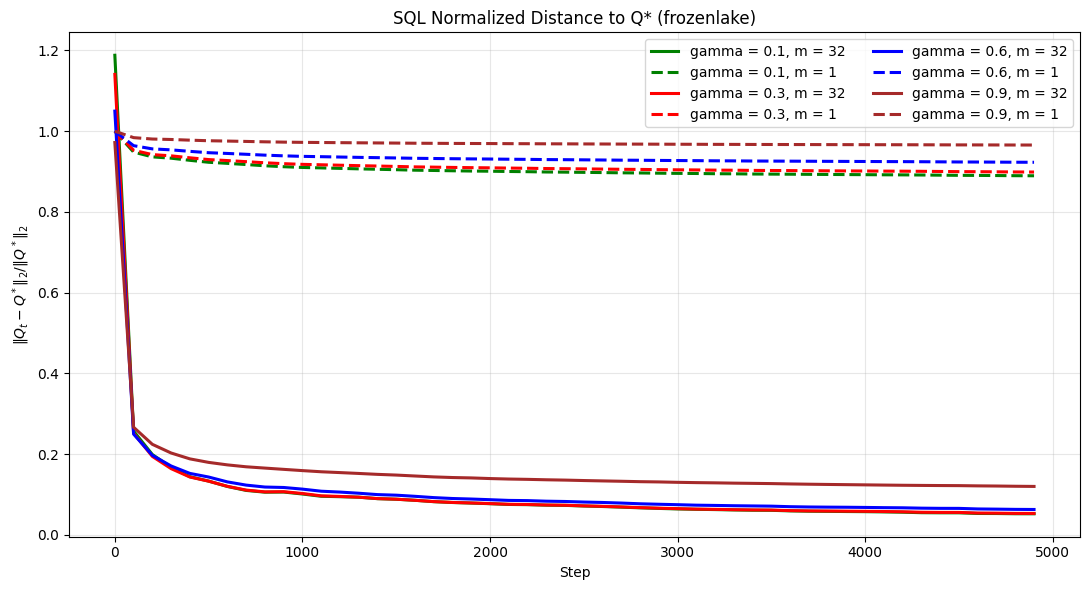

In [3]:
ENV_NAME = "frozenlake"
MAP_NAME = "4x4"
SLIPPERY = True

sql_compare_runs, qstar_norms = run_sql_curves(
    env_name=ENV_NAME,
    map_name=MAP_NAME,
    slippery=SLIPPERY,
    gammas=ALL_GAMMAS,
    m_values=[BASELINE_LONG, BATCH_LONG],
    steps=LONG_STEPS,
    out_root=SQL_COMPARE_DIR,
)

plt.figure(figsize=(11, 6))

for gamma in ALL_GAMMAS:
    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y = sql_compare_runs[gamma][m]["norm_mean"]
        x = np.arange(len(y))

        plt.plot(
            x[::STRIDE_LONG],
            y[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"gamma = {gamma}, m = {m}",
        )

plt.title("SQL Normalized Distance to Q* (frozenlake)")
plt.xlabel("Step")
plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

filename = os.path.join(FIGURES_DIR, "sql_frozenlake_gamma_comparison_normalized.png")
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

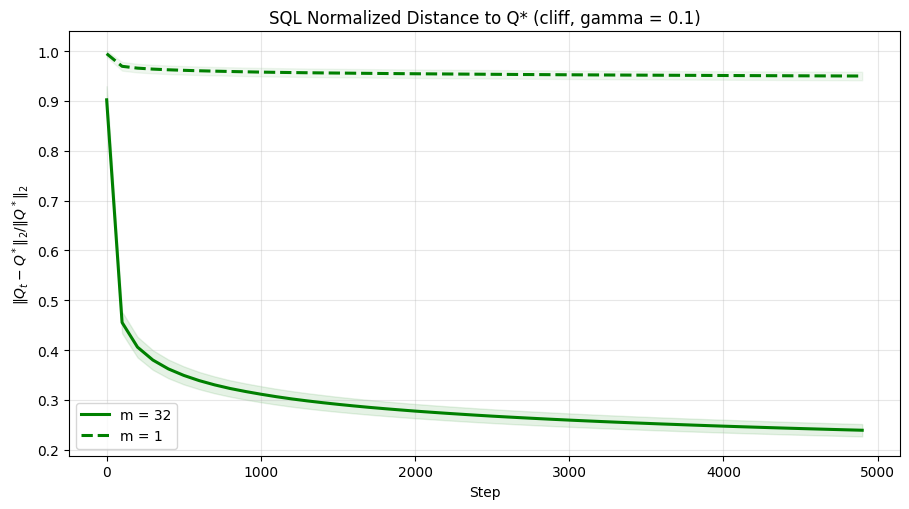

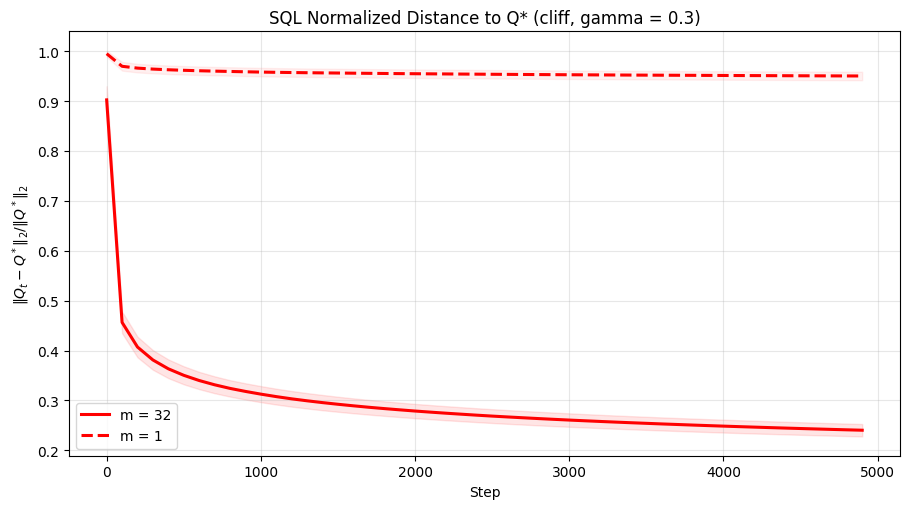

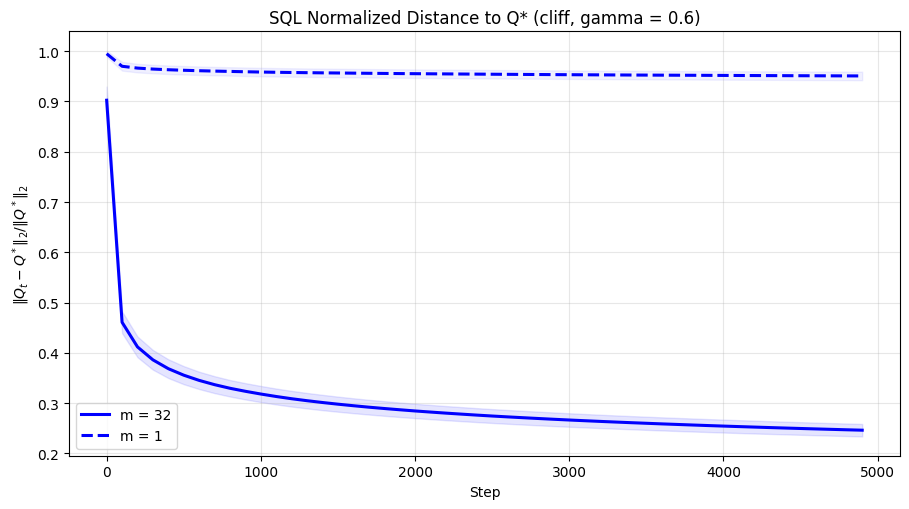

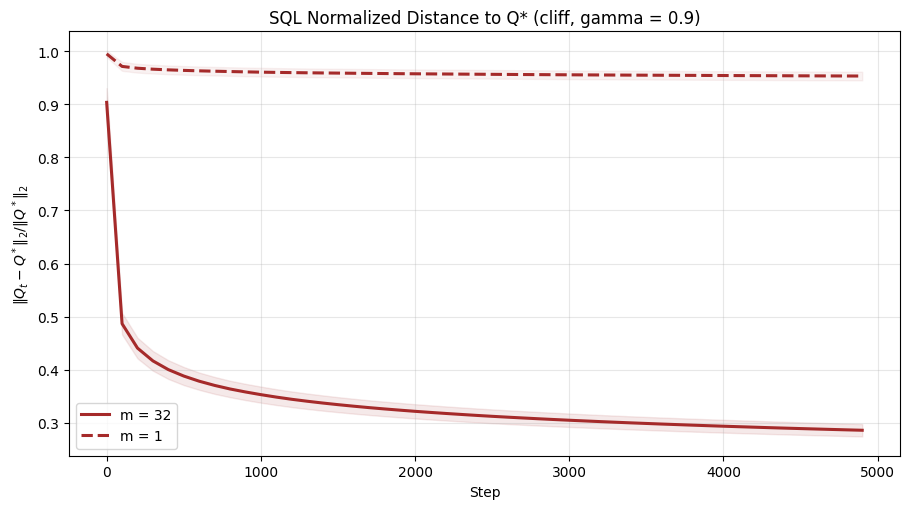

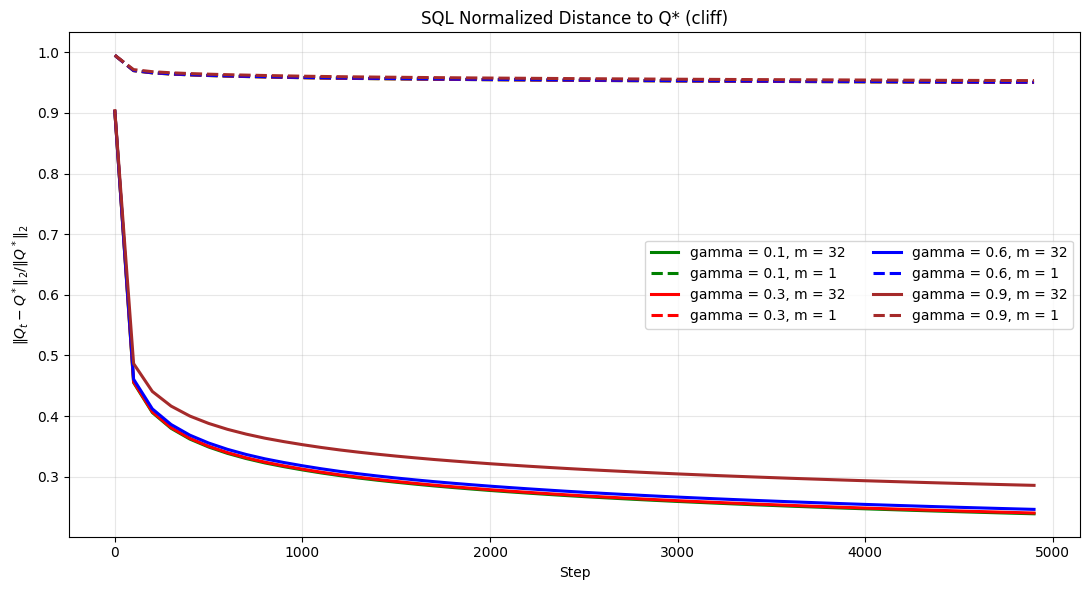

In [4]:
ENV_NAME = "cliff"
MAP_NAME = "4x4"
SLIPPERY = True

sql_cliff_runs, cliff_qstar_norms = run_sql_curves(
    env_name=ENV_NAME,
    map_name=MAP_NAME,
    slippery=SLIPPERY,
    gammas=ALL_GAMMAS,
    m_values=[BASELINE_LONG, BATCH_LONG],
    steps=LONG_STEPS,
    out_root=SQL_COMPARE_DIR,
)

for gamma in ALL_GAMMAS:
    plt.figure(figsize=(9.2, 5.2))

    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y_mean = sql_cliff_runs[gamma][m]["norm_mean"]
        y_std = sql_cliff_runs[gamma][m]["norm_std"]
        x = np.arange(len(y_mean))

        plt.plot(
            x[::STRIDE_LONG],
            y_mean[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"m = {m}",
        )
        plt.fill_between(
            x[::STRIDE_LONG],
            y_mean[::STRIDE_LONG] - y_std[::STRIDE_LONG],
            y_mean[::STRIDE_LONG] + y_std[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            alpha=0.10 if m == BATCH_LONG else 0.06,
        )

    plt.title(f"SQL Normalized Distance to Q* (cliff, gamma = {gamma})")
    plt.xlabel("Step")
    plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = os.path.join(FIGURES_DIR, f"sql_cliff_gamma{gamma}_m1_m32_normalized.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(11, 6))

for gamma in ALL_GAMMAS:
    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y = sql_cliff_runs[gamma][m]["norm_mean"]
        x = np.arange(len(y))

        plt.plot(
            x[::STRIDE_LONG],
            y[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"gamma = {gamma}, m = {m}",
        )

plt.title("SQL Normalized Distance to Q* (cliff)")
plt.xlabel("Step")
plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

filename = os.path.join(FIGURES_DIR, "sql_cliff_gamma_comparison_normalized.png")
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

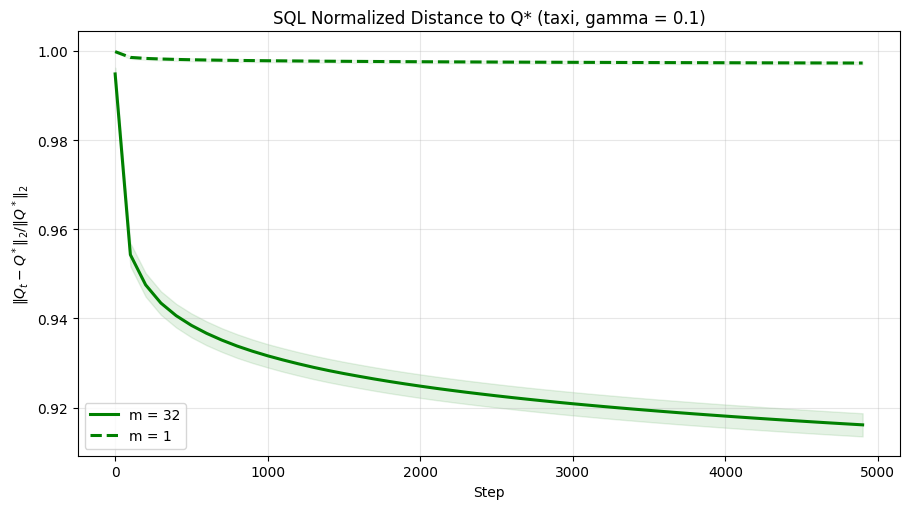

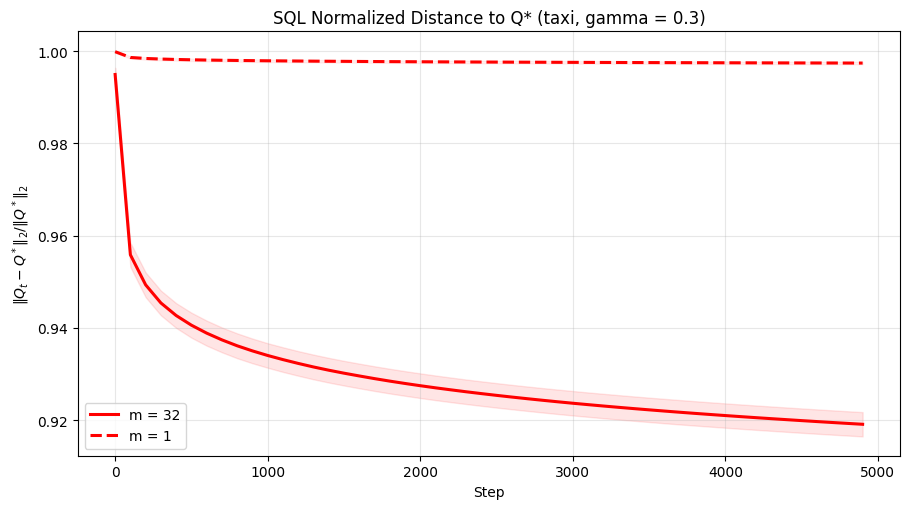

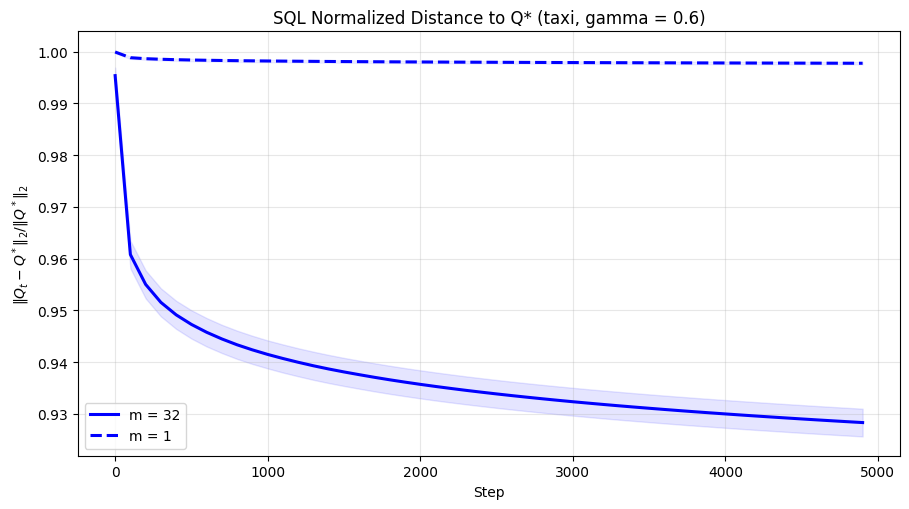

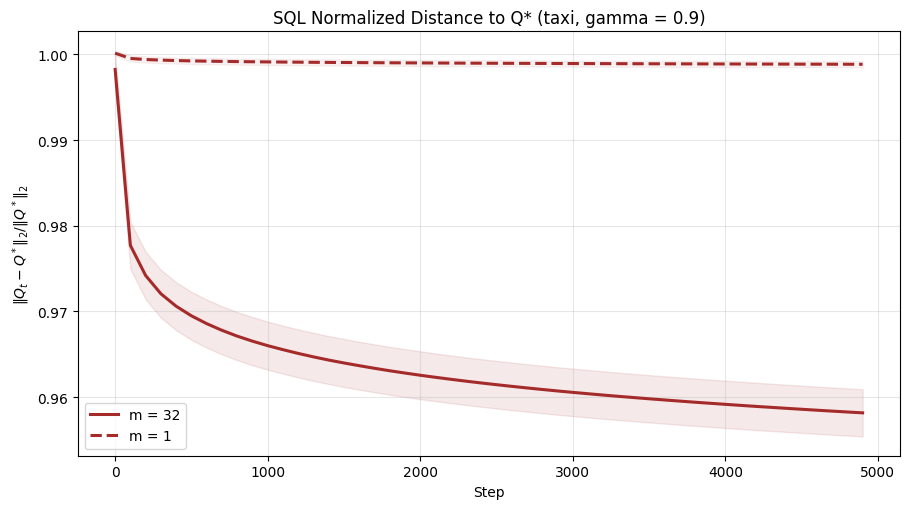

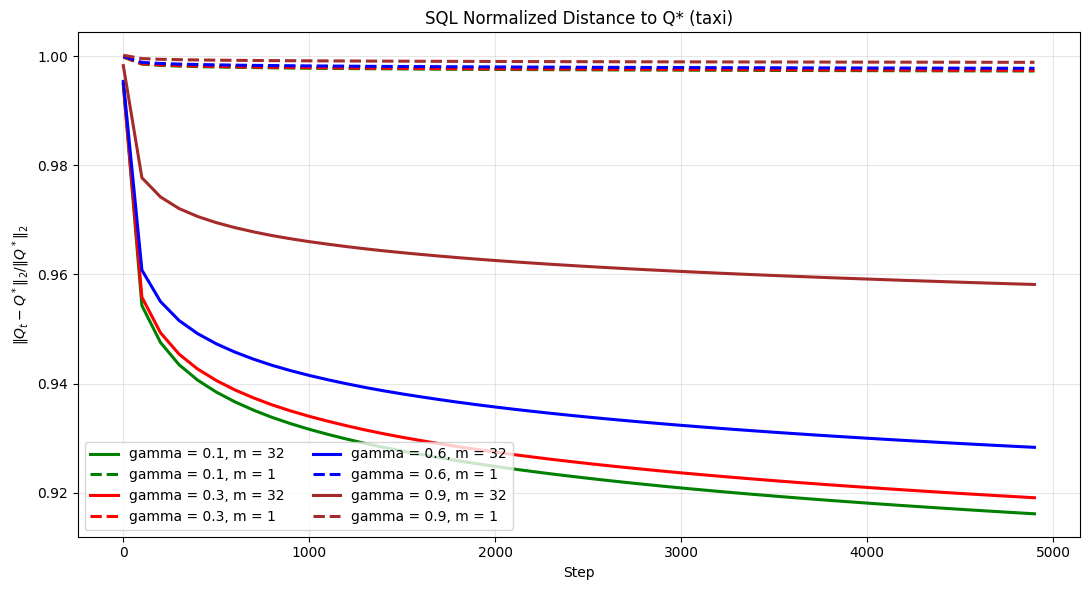

In [5]:
ENV_NAME = "taxi"
MAP_NAME = "4x4"
SLIPPERY = True

sql_taxi_runs, taxi_qstar_norms = run_sql_curves(
    env_name=ENV_NAME,
    map_name=MAP_NAME,
    slippery=SLIPPERY,
    gammas=ALL_GAMMAS,
    m_values=[BASELINE_LONG, BATCH_LONG],
    steps=LONG_STEPS,
    out_root=SQL_COMPARE_DIR,
)

for gamma in ALL_GAMMAS:
    plt.figure(figsize=(9.2, 5.2))

    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y_mean = sql_taxi_runs[gamma][m]["norm_mean"]
        y_std = sql_taxi_runs[gamma][m]["norm_std"]
        x = np.arange(len(y_mean))

        plt.plot(
            x[::STRIDE_LONG],
            y_mean[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"m = {m}",
        )
        plt.fill_between(
            x[::STRIDE_LONG],
            y_mean[::STRIDE_LONG] - y_std[::STRIDE_LONG],
            y_mean[::STRIDE_LONG] + y_std[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            alpha=0.10 if m == BATCH_LONG else 0.06,
        )

    plt.title(f"SQL Normalized Distance to Q* (taxi, gamma = {gamma})")
    plt.xlabel("Step")
    plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = os.path.join(FIGURES_DIR, f"sql_taxi_gamma{gamma}_m1_m32_normalized.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(11, 6))

for gamma in ALL_GAMMAS:
    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y = sql_taxi_runs[gamma][m]["norm_mean"]
        x = np.arange(len(y))

        plt.plot(
            x[::STRIDE_LONG],
            y[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"gamma = {gamma}, m = {m}",
        )

plt.title("SQL Normalized Distance to Q* (taxi)")
plt.xlabel("Step")
plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

filename = os.path.join(FIGURES_DIR, "sql_taxi_gamma_comparison_normalized.png")
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()